# ZERO shot

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('models/results/evaluation_results.csv')
df

,model_name,num_params,languages,map_es_es,mrr,ndcg,p@5,p@10,p@100,source
0,Lajavaness/bilingual-embedding-large,559890432,bilingual,0.449344,0.546847,0.744623,0.650811,0.637838,0.244865,mteb
1,jinaai/jina-embeddings-v3,572310396,multilingual,0.445291,0.547297,0.740716,0.656216,0.615135,0.241892,mteb
2,chienpham/sts-multilingual-mpnet-base-v2,278043648,multilingual,0.443588,0.551532,0.734145,0.654054,0.636757,0.236757,mteb
3,intfloat/multilingual-e5-large-instruct,559890432,multilingual,0.442597,0.538243,0.739878,0.658378,0.622162,0.242108,mteb
4,AIDA-UPM/mstsb-paraphrase-multilingual-mpnet-b...,278043648,multilingual,0.428735,0.547207,0.726293,0.640000,0.631892,0.231135,mteb
...,...,...,...,...,...,...,...,...,...,...
185,dccuchile/albert-base-spanish-distilled-qa-sqac,11811584,monolingual,0.066581,0.386718,0.439594,0.250811,0.200541,0.053622,spanish
186,dccuchile/albert-base-10-spanish-distilled-ner,11811584,monolingual,0.063189,0.396291,0.443869,0.237838,0.179459,0.055946,spanish
187,dccuchile/albert-base-10-spanish-distilled-qa-tar,11811584,monolingual,0.062703,0.395395,0.431764,0.242162,0.179459,0.048324,spanish
188,dccuchile/albert-base-spanish-distilled-ner,11811584,monolingual,0.054585,0.340839,0.425897,0.191351,0.150811,0.051027,spanish


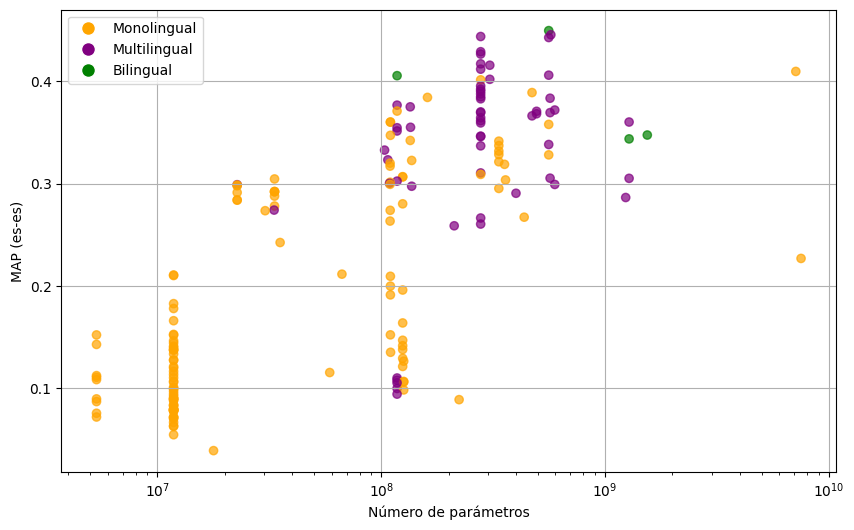

In [3]:
# ahora que se pinten en distintos colores los monolinuges y los multilingues
plt.figure(figsize=(10, 6))
plt.scatter(df['num_params'], df['map_es_es'], c=df['languages'].map({'monolingual': 'orange', 'multilingual': 'purple', 'bilingual': 'green'}), alpha=0.7)
plt.xlabel('Número de parámetros')
plt.ylabel('MAP (es-es)')
plt.xscale('log')  # Escala logarítmica para el eje x
plt.grid(True)
# mostrar Leyenda de los tres colores
handles = [plt.Line2D([0], [0], marker='o', color='w', label='Monolingual', markerfacecolor='orange', markersize=10),
           plt.Line2D([0], [0], marker='o', color='w', label='Multilingual', markerfacecolor='purple', markersize=10),
           plt.Line2D([0], [0], marker='o', color='w', label='Bilingual', markerfacecolor='green', markersize=10)]
plt.legend(handles=handles)
plt.show()

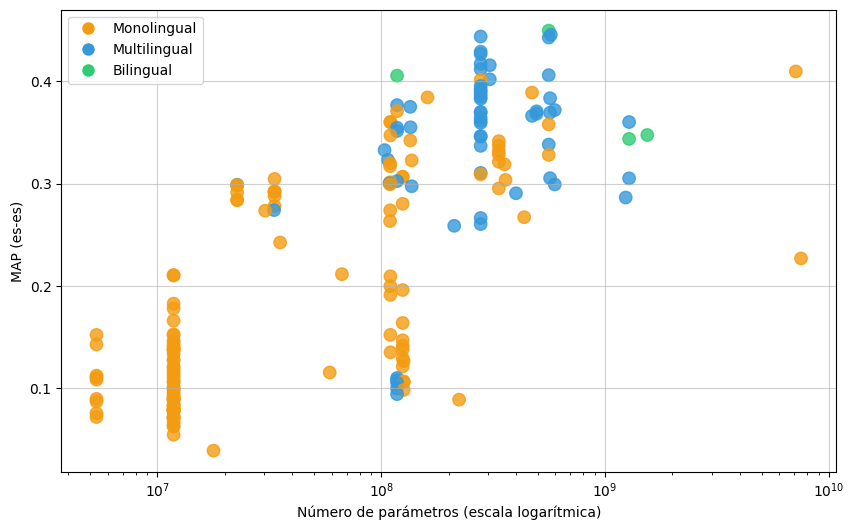

In [80]:
colors = ['#3498db', '#2ecc71', '#f39c12']

plt.figure(figsize=(10, 6))
plt.scatter(df['num_params'], df['map_es_es'], 
            c=df['languages'].map({'monolingual': colors[2], 'multilingual': colors[0], 'bilingual': colors[1]}), 
            alpha=0.8, s=80)
plt.xlabel('Número de parámetros (escala logarítmica)')
plt.ylabel('MAP (es-es)')
plt.xscale('log')  # Escala logarítmica para el eje x
plt.grid(True, alpha=0.6)
# mostrar Leyenda de los tres colores
handles = [plt.Line2D([0], [0], marker='o', color='w', label='Monolingual', markerfacecolor=colors[2], markersize=10),
           plt.Line2D([0], [0], marker='o', color='w', label='Multilingual', markerfacecolor=colors[0], markersize=10),
           plt.Line2D([0], [0], marker='o', color='w', label='Bilingual', markerfacecolor=colors[1], markersize=10)]
plt.legend(handles=handles)
plt.show()

# Resultados tras el finetuning

In [82]:
df = pd.read_csv('models/results/finetuned_results.csv')
df = df.sort_values(by='finetuned_map', ascending=False)

In [83]:
# imprimir en latex solo la columna model_name, previous_map finetuned_map, redondeando a 4 decimales
df_latex_finetuned = df[['model_name', 'previous_map', 'finetuned_map']].copy()
df_latex_finetuned['previous_map'] = df_latex_finetuned['previous_map'].round(4)
df_latex_finetuned['finetuned_map'] = df_latex_finetuned['finetuned_map'].round(4)
# agregar columna de posicion
df_latex_finetuned['ranking'] = range(1, len(df_latex_finetuned) + 1)
df_latex_finetuned = df_latex_finetuned[['ranking', 'model_name', 'previous_map', 'finetuned_map']]
# print(df_latex_finetuned.to_latex(index=False))

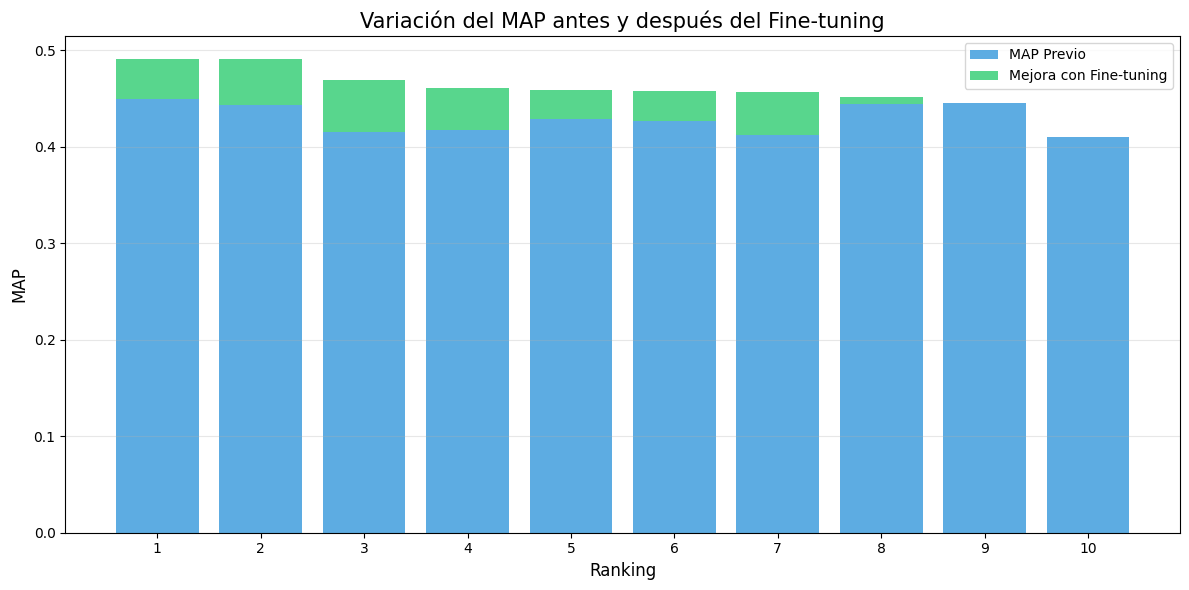

In [67]:
# Graficar la variación del MAP antes y después del finetuning con barras
import matplotlib.pyplot as plt
import numpy as np

# Calcular la diferencia (siempre positiva)
df_latex_finetuned['map_difference'] = df_latex_finetuned['finetuned_map'] - df_latex_finetuned['previous_map']

# Crear la figura
plt.figure(figsize=(12, 6))

# Posiciones de las barras
x_pos = np.arange(len(df_latex_finetuned['ranking']))

# Crear barras apiladas
plt.bar(x_pos, df_latex_finetuned['previous_map'], 
        label='MAP Previo', color='#3498db', alpha=0.8)
plt.bar(x_pos, df_latex_finetuned['map_difference'], 
        bottom=df_latex_finetuned['previous_map'],
        label='Mejora con Fine-tuning', color='#2ecc71', alpha=0.8)

# Personalizar el gráfico
plt.xlabel('Ranking', fontsize=12)
plt.ylabel('MAP', fontsize=12)
plt.title('Variación del MAP antes y después del Fine-tuning', fontsize=15)
plt.xticks(x_pos, df_latex_finetuned['ranking'])
plt.legend(loc='best')
plt.grid(True, alpha=0.3, axis='y')

# Ajustar el diseño
plt.tight_layout()
plt.show()

In [15]:
# media de variacion por parte de los modelos
mean_variation = (df_latex_finetuned['finetuned_map'] - df_latex_finetuned['previous_map']).mean()
mean_variation

np.float64(0.030040000000000004)

# Fusion Ranking

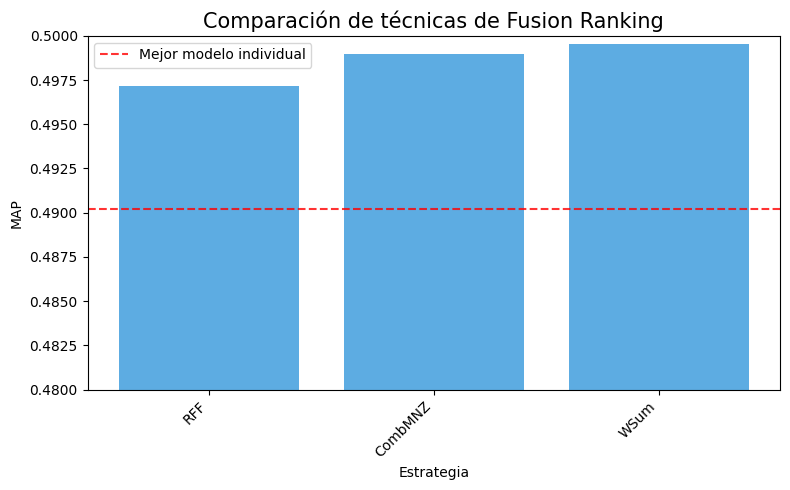

In [66]:
import matplotlib.pyplot as plt

# Datos
x_val = ['RFF', 'CombMNZ', 'WSum']
y_val = [0.49716620947295626, 0.49896024968932706, 0.49953778650701297]

# Valor del best model (asíntota horizontal)
best_model_value = 0.490223

# Crear la figura
plt.figure(figsize=(8, 5))

# Gráfica de barras
plt.bar(x_val, y_val, color='#3498db', alpha=0.8)

# Escala logarítmica en el eje Y
# plt.yscale('log')
plt.ylim(bottom=0.48, top=0.5)

# Línea horizontal (asíntota) del best model
plt.axhline(
    y=best_model_value,
    linestyle='--',
    linewidth=1.5,
    label='Mejor modelo individual',
    color='red',
    alpha=0.8
)

# Etiquetas y título
plt.xlabel('Estrategia')
plt.ylabel('MAP')
plt.title('Comparación de técnicas de Fusion Ranking', fontsize=15)

bar_positions = np.arange(len(x_val))
plt.xticks(bar_positions, x_val, rotation=45, ha='right')
plt.legend()

# Mostrar la gráfica
plt.tight_layout()
plt.show()

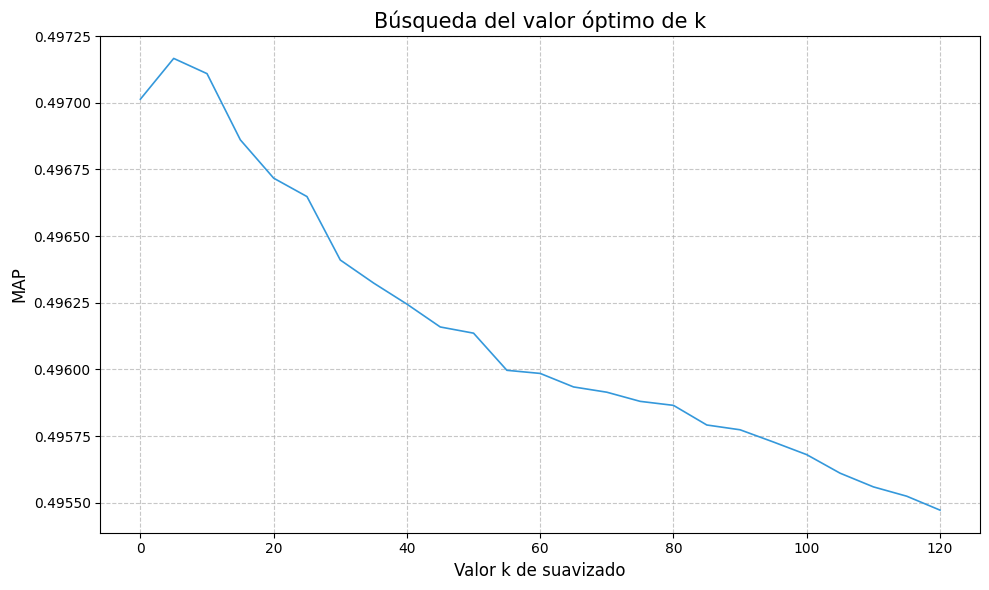

In [65]:
import matplotlib.pyplot as plt

datos = [[0, 0.49701334750158216],
[5, 0.49716620947295626],
[10, 0.4971091049641763],
[15, 0.4968608799906601],
[20, 0.4967172568485116],
[25, 0.49664821696273154],
[30, 0.49641033069693513],
[35, 0.4963239689943632],
[40, 0.4962449327325624],
[45, 0.49615928854947444],
[50, 0.496136050393252],
[55, 0.49599680233652066],
[60, 0.495985105729283],
[65, 0.4959344780393815],
[70, 0.49591467303296705],
[75, 0.4958803749135134],
[80, 0.49586535894353057],
[85, 0.4957917650207261],
[90, 0.495773751563253],
[95, 0.49572795154696947],
[100, 0.49568051370276744],
[105, 0.49561110313271006],
[110, 0.49555974143920295],
[115, 0.4955247939860256],
[120, 0.49547251239955936]]

x_vals, y_vals = map(list, zip(*datos))

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, linestyle='-', color='#3498db', linewidth=1.2, markersize=4)

# Mejorar visualización
plt.title('Búsqueda del valor óptimo de k', fontsize=15)
plt.xlabel('Valor k de suavizado', fontsize=12)
plt.ylabel('MAP', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Modelos reranking

In [2]:
import pandas as pd

df = pd.read_csv('/home/david/Documents/Master/TFM/output/ranking_results/massive evaluation/reranking/reranking_models.csv')
df = df.drop(columns=['map_reranking_75'])
df = df[df['map_reranking_100'] != 0]
df

,model_name,num_params,map_reranking_10,map_reranking_25,map_reranking_50,map_reranking_100
0,cross-encoder/ms-marco-TinyBERT-L2-v2,4386561,0.493541,0.478089,0.450638,0.410428
1,cross-encoder/ms-marco-TinyBERT-L2,4386561,0.506406,0.493502,0.468728,0.423818
2,cross-encoder/stsb-TinyBERT-L4,14351073,0.496355,0.484389,0.462838,0.419737
3,cross-encoder/ms-marco-TinyBERT-L4,14351073,0.496196,0.478972,0.449470,0.406710
4,cross-encoder/ms-marco-MiniLM-L2-v2,15616257,0.493001,0.474821,0.447928,0.406967
...,...,...,...,...,...,...
68,XingTuLab/BinSeek-Reranker,595777536,0.508277,0.454223,0.385353,0.294332
69,tomaarsen/Qwen3-Reranker-0.6B-seq-cls,595777536,0.519043,0.454282,0.362816,0.266693
70,openbmb/MiniCPM-Reranker-Light,1360247808,0.500803,0.469515,0.419845,0.339184
72,AhmedMostafa/bge-reranker-v2-gemma-saudi-achi10,2506176512,0.519805,0.449699,0.358271,0.260678


In [104]:
import matplotlib.pyplot as plt
import numpy as np

# Preparar datos
models = df['model_name'].str.split('/').str[-1]  # Simplificar nombres
k_values = ['10', '25', '50', '100']
map_columns = ['map_reranking_10', 'map_reranking_25', 'map_reranking_50', 'map_reranking_100']
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

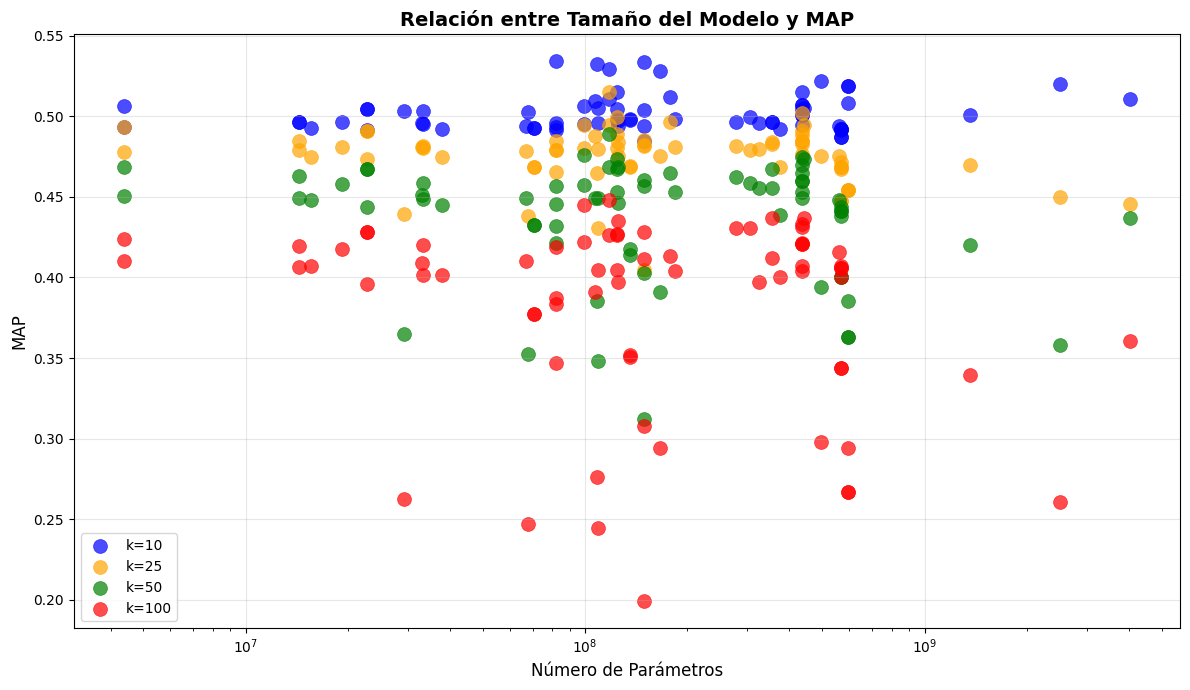

In [86]:
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['blue', 'orange', 'green', 'red']

for col, k, color in zip(map_columns, k_values, colors):
    ax.scatter(df['num_params'], df[col], s=100, alpha=0.7, 
               color=color, label=f'k={k}', linewidth=0.5)

ax.set_xlabel('Número de Parámetros', fontsize=12)
ax.set_ylabel('MAP', fontsize=12)
ax.set_title('Relación entre Tamaño del Modelo y MAP', fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

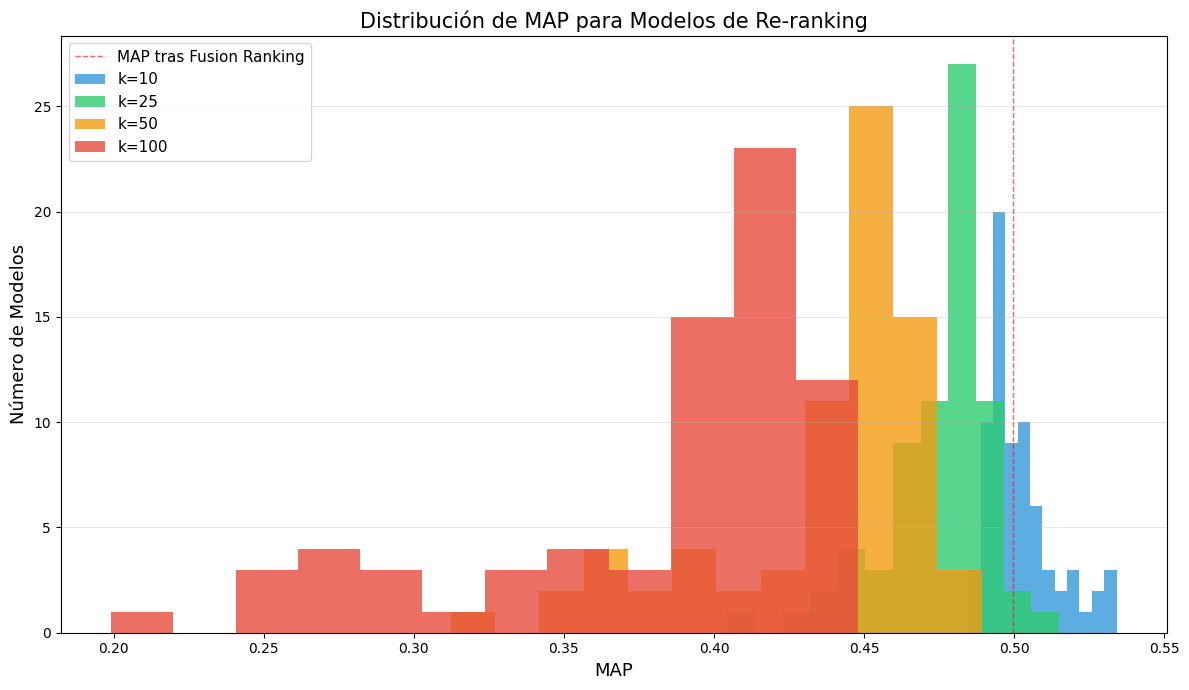

In [105]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

# añadir linea vertical en el valor de 0.4995
ax.axvline(x=0.4995, color='red', linestyle='--', linewidth=1, label='MAP tras Fusion Ranking', alpha=0.6)


colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
k_values = ['10', '25', '50', '100']
map_columns = ['map_reranking_10', 'map_reranking_25', 'map_reranking_50', 'map_reranking_100']

for col, k, color in zip(map_columns, k_values, colors):
    ax.hist(df[col], bins=12, alpha=0.8, label=f'k={k}', color=color, linewidth=0.5)

ax.set_xlabel('MAP', fontsize=13)
ax.set_ylabel('Número de Modelos', fontsize=13)
ax.set_title(f'Distribución de MAP para Modelos de Re-ranking', fontsize=15)



ax.legend(fontsize=11, title_fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6622/3109376465.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=k_labels, patch_artist=True)


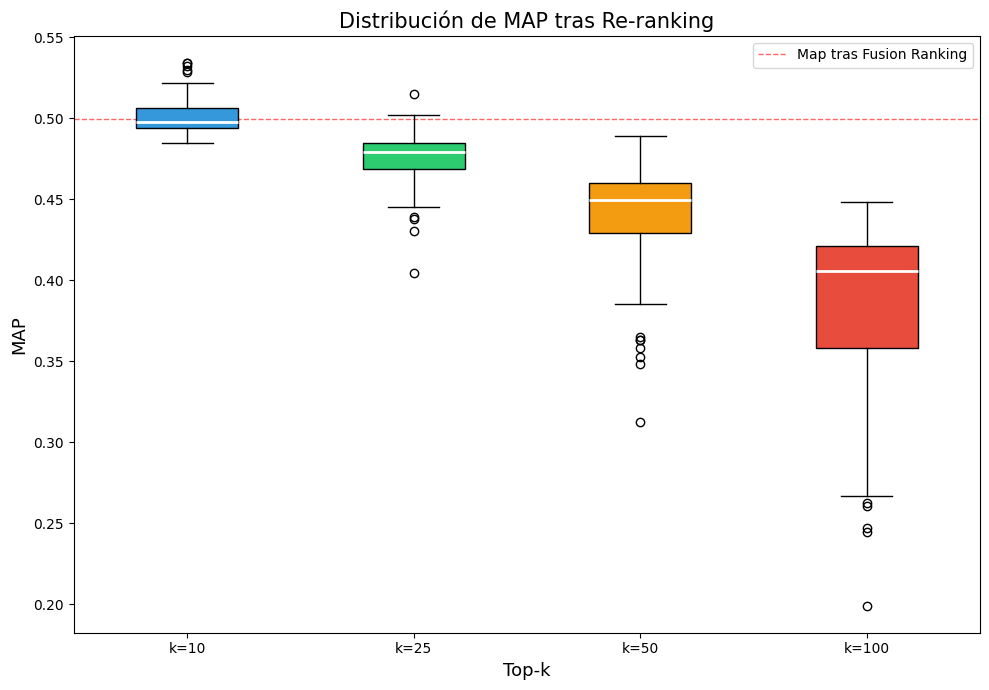

In [107]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

# Añadir línea horizontal en 0.4995
ax.axhline(y=0.4995, color='red', linestyle='--', linewidth=1, label='Map tras Fusion Ranking', alpha=0.6)

# Preparar datos
map_columns = ['map_reranking_10', 'map_reranking_25', 'map_reranking_50', 'map_reranking_100']
data_to_plot = [df[col] for col in map_columns]
k_labels = ['k=10', 'k=25', 'k=50', 'k=100']
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

# Crear box plots
bp = ax.boxplot(data_to_plot, labels=k_labels, patch_artist=True)

# Colorear el relleno de las cajas
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Cambiar la mediana a blanco
for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2)



ax.set_ylabel('MAP', fontsize=13)
ax.set_xlabel('Top-k', fontsize=13)
ax.set_title(f'Distribución de MAP tras Re-ranking', fontsize=15)
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_35779/2589049059.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=k_labels, patch_artist=True)


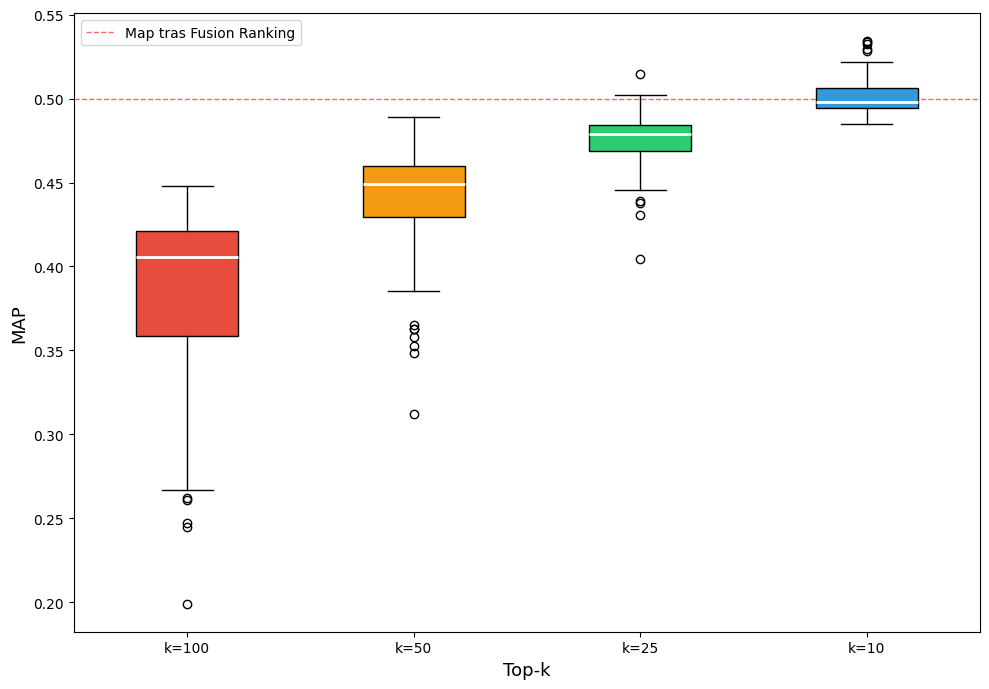

In [4]:
# repetir el boxplot anterior pero ordenando de mayor a menor el valor de k

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 7))
# Añadir línea horizontal en 0.4995
ax.axhline(y=0.4995, color='red', linestyle='--', linewidth=1, label='Map tras Fusion Ranking', alpha=0.6)
# Preparar datos ordenados de mayor a menor k
map_columns = ['map_reranking_100', 'map_reranking_50', 'map_reranking_25', 'map_reranking_10']
data_to_plot = [df[col] for col in map_columns]
k_labels = ['k=100', 'k=50', 'k=25', 'k=10']
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
# Crear box plots
bp = ax.boxplot(data_to_plot, labels=k_labels, patch_artist=True)
# Colorear el relleno de las cajas
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
# Cambiar la mediana a blanco
for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2)
ax.set_ylabel('MAP', fontsize=13)
ax.set_xlabel('Top-k', fontsize=13)
# ax.set_title(f'Distribución de MAP tras Re-ranking (Ordenado por k)', fontsize=15)
ax.legend()
plt.tight_layout()
plt.show()

## Top 10 en fusion Ranking

In [6]:
import pandas as pd

df = pd.read_csv('/home/david/Documents/Master/TFM/output/ranking_results/massive evaluation/reranking/reranking_models_top10.csv')

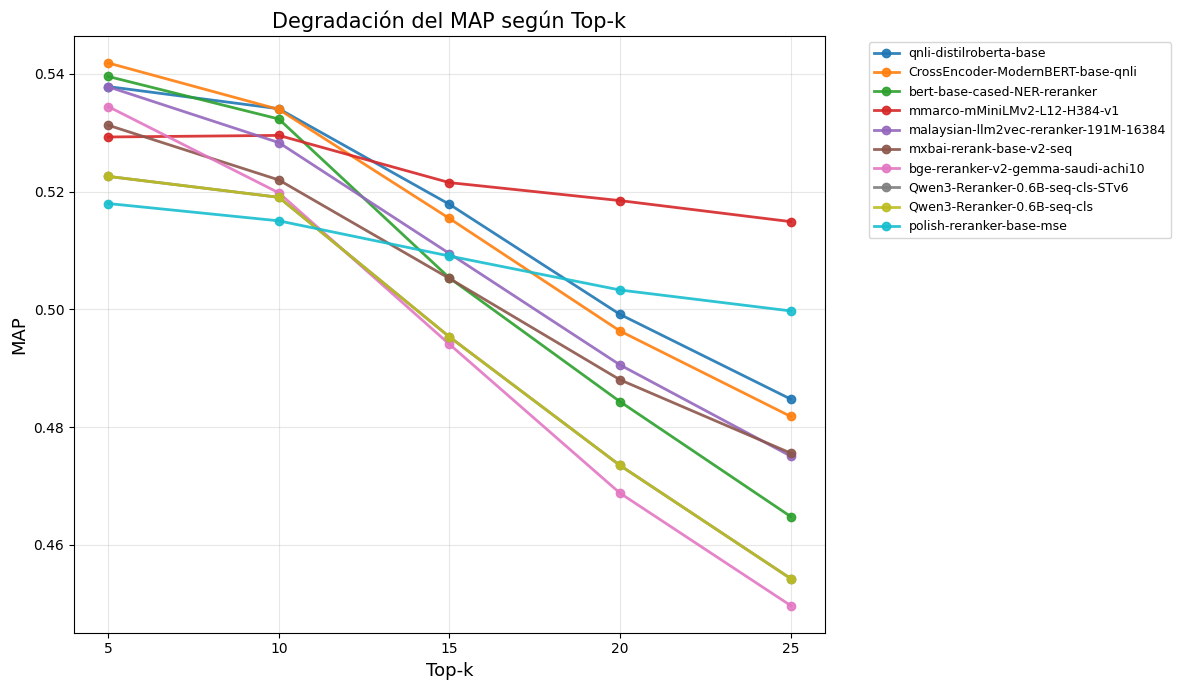

In [115]:
import matplotlib.pyplot as plt

# Columnas de MAP para diferentes valores de k
map_columns = ['map_reranking_5', 'map_reranking_10', 'map_reranking_15', 'map_reranking_20', 'map_reranking_25']
k_values = [5, 10, 15, 20, 25]

plt.figure(figsize=(12, 7))

# Graficar una línea por cada modelo
for idx, row in df.iterrows():
    model_name = row['model_name'].split('/')[-1]  # Simplificar nombre del modelo
    map_values = [row[col] for col in map_columns]
    plt.plot(k_values, map_values, marker='o', label=model_name, linewidth=2, markersize=6, alpha=0.9)

plt.xlabel('Top-k', fontsize=13)
plt.ylabel('MAP', fontsize=13)
plt.title('Degradación del MAP según Top-k', fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

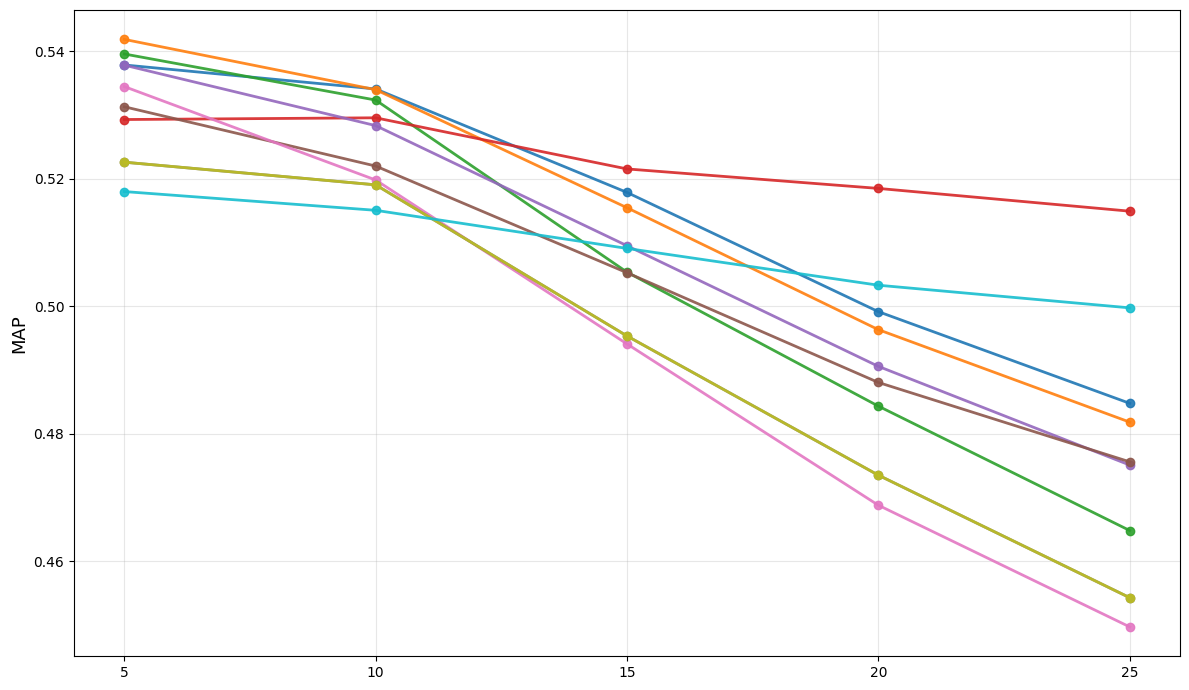

In [8]:
import matplotlib.pyplot as plt

# Columnas de MAP para diferentes valores de k
map_columns = ['map_reranking_5', 'map_reranking_10', 'map_reranking_15', 'map_reranking_20', 'map_reranking_25']
k_values = [5, 10, 15, 20, 25]

plt.figure(figsize=(12, 7))

# Graficar una línea por cada modelo
for idx, row in df.iterrows():
    model_name = row['model_name'].split('/')[-1]  # Simplificar nombre del modelo
    map_values = [row[col] for col in map_columns]
    plt.plot(k_values, map_values, marker='o', label=model_name, linewidth=2, markersize=6, alpha=0.9)

# plt.xlabel('Top-k', fontsize=13)
plt.ylabel('MAP', fontsize=13)
# plt.title('Degradación del MAP según Top-k', fontsize=15)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6622/3881035559.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=k_labels, patch_artist=True)


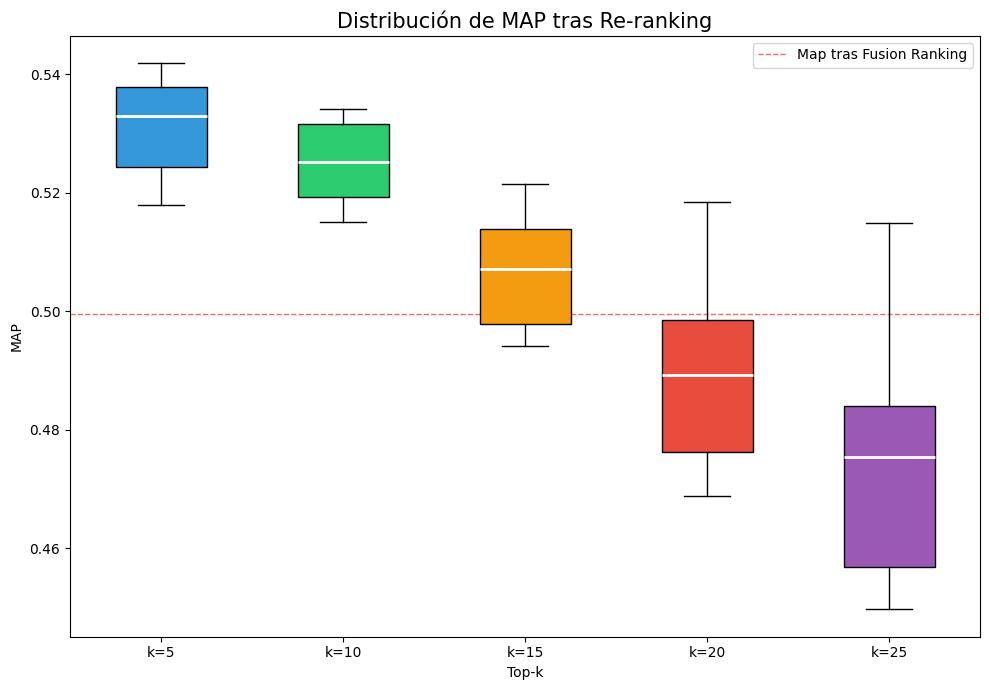

In [116]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

# Añadir línea horizontal en 0.4995
ax.axhline(y=0.4995, color='red', linestyle='--', linewidth=1, label='Map tras Fusion Ranking', alpha=0.6)

# Preparar datos
map_columns = ['map_reranking_5', 'map_reranking_10', 'map_reranking_15', 'map_reranking_20', 'map_reranking_25']
data_to_plot = [df[col] for col in map_columns]
k_labels = ['k=5', 'k=10', 'k=15', 'k=20', 'k=25']
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']

# Crear box plots
bp = ax.boxplot(data_to_plot, labels=k_labels, patch_artist=True)

# Colorear el relleno de las cajas
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Cambiar la mediana a blanco
for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2)



ax.set_ylabel('MAP')
ax.set_xlabel('Top-k')
ax.set_title(f'Distribución de MAP tras Re-ranking', fontsize=15)
ax.legend()
plt.tight_layout()
plt.show()

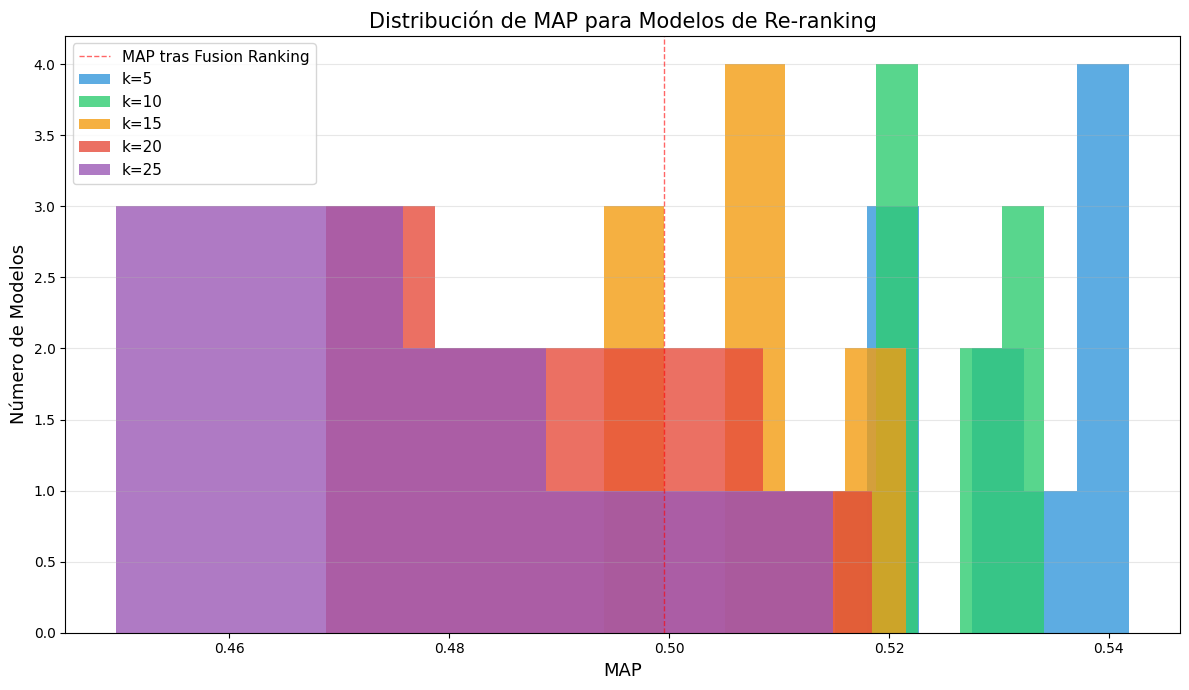

In [119]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

# añadir linea vertical en el valor de 0.4995
ax.axvline(x=0.4995, color='red', linestyle='--', linewidth=1, label='MAP tras Fusion Ranking', alpha=0.6)


colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
k_values = ['5', '10', '15', '20', '25']
map_columns = ['map_reranking_5', 'map_reranking_10', 'map_reranking_15', 'map_reranking_20', 'map_reranking_25']

for col, k, color in zip(map_columns, k_values, colors):
    ax.hist(df[col], bins=5, alpha=0.8, label=f'k={k}', color=color, linewidth=0.5)

ax.set_xlabel('MAP', fontsize=13)
ax.set_ylabel('Número de Modelos', fontsize=13)
ax.set_title(f'Distribución de MAP para Modelos de Re-ranking', fontsize=15)



ax.legend(fontsize=11, title_fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Defense

In [19]:
sizes = [49.2, 6.0, 5.8, 5.1, 4.5, 4.1, 25.3]
sum(sizes)

100.0

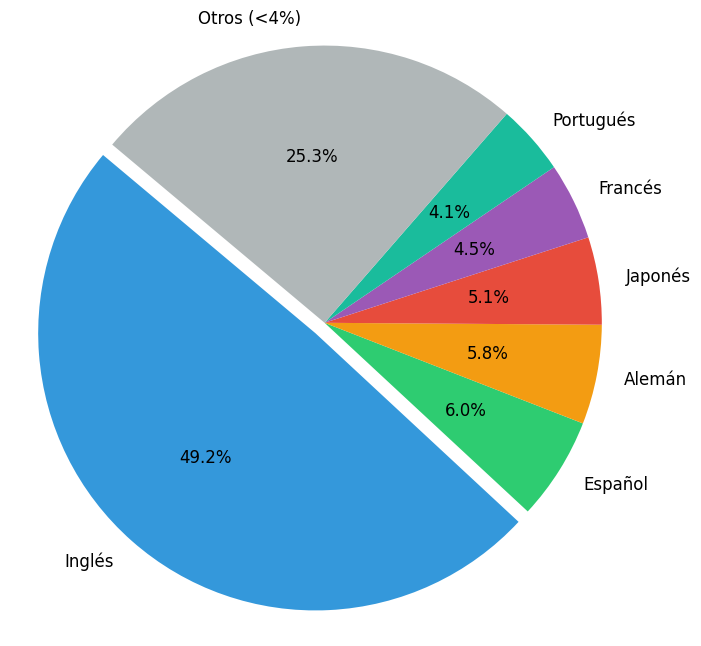

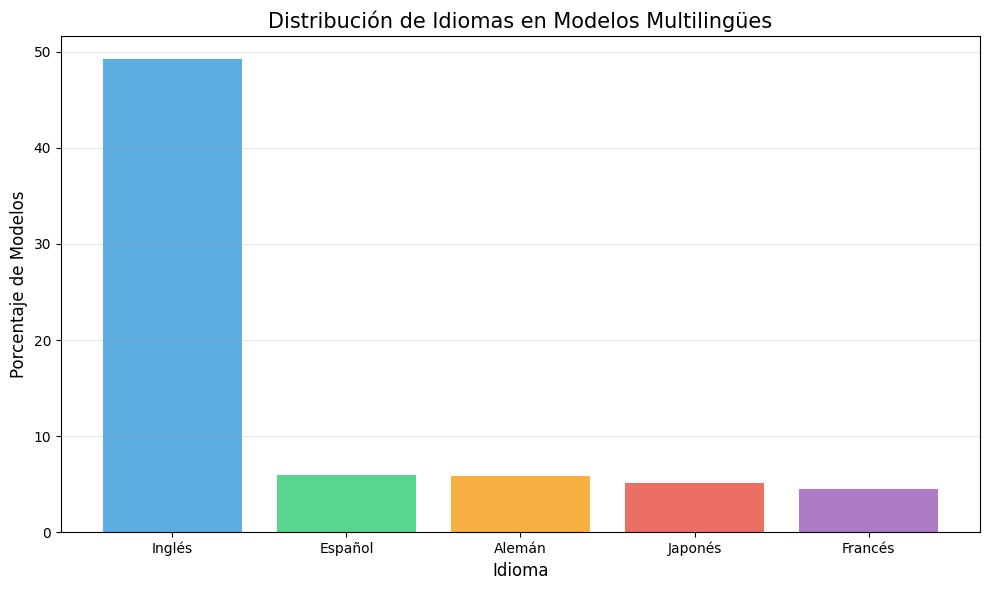

In [22]:
# English   49.2%
# Spanish    6.0%
# German     5.8%
# Japanese   5.1%
# French     4.5%
# Portuguese	4.1%


from matplotlib import pyplot as plt
labels = ['Inglés', 'Español', 'Alemán', 'Japonés', 'Francés', 'Portugués', 'Otros (<4%)']
sizes = [49.2, 6.0, 5.8, 5.1, 4.5, 4.1, 25.3]
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', "#1abc9c", "#b0b7b8"]
explode = (0.05, 0, 0, 0, 0, 0, 0) 
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=False, startangle=140, textprops={'fontsize': 12})
# plt.title('Distribución de Idiomas en Modelos Multilingües', fontsize=15)
plt.axis('equal')
plt.show()

# ahora en grafico de barras sin otros idiomas
labels = ['Inglés', 'Español', 'Alemán', 'Japonés', 'Francés']
sizes = [49.2, 6.0, 5.8, 5.1, 4.5]
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
plt.figure(figsize=(10, 6))
plt.bar(labels, sizes, color=colors, alpha=0.8)
plt.xlabel('Idioma', fontsize=12)
plt.ylabel('Porcentaje de Modelos', fontsize=12)
plt.title('Distribución de Idiomas en Modelos Multilingües', fontsize=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

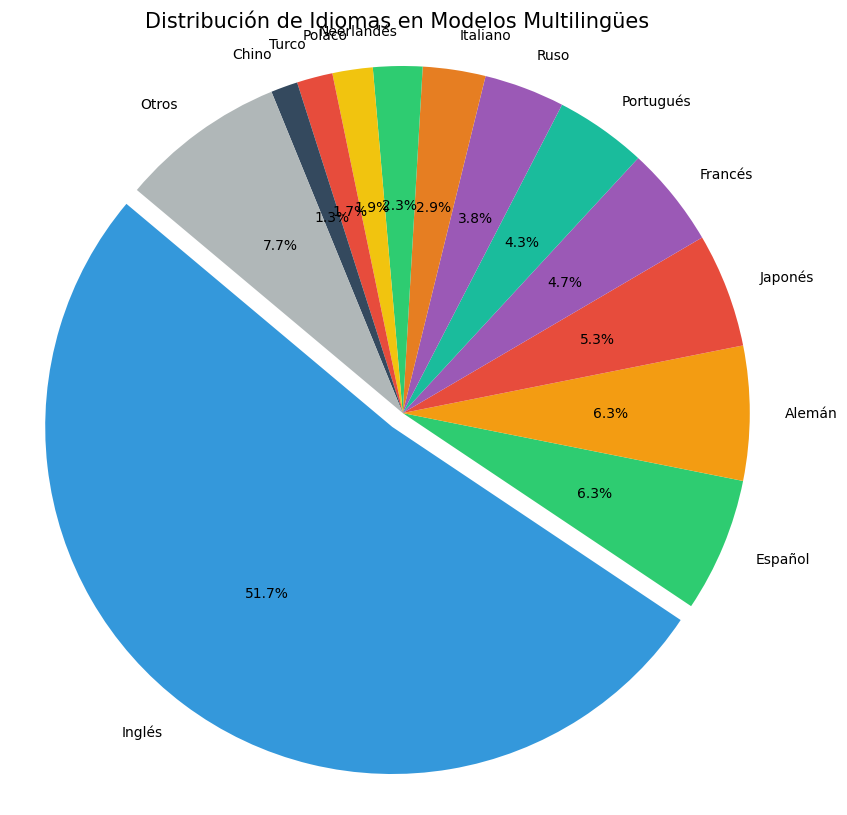

In [11]:
# hacer ahora un diagrama de quesos pero con estos idiomas, poniendo Otros para lenguajes menores a un 1%
# English	
# 49.6%
# Spanish	
# 6.0%
# German	
# 6.0%
# Japanese	
# 5.1%
# French	
# 4.5%
# Portuguese	
# 4.1%
# Russian	
# 3.6%
# Italian	
# 2.8%
# Dutch, Flemish	
# 2.2%
# Polish	
# 1.8%
# Turkish	
# 1.6%
# Chinese	
# 1.2%
# Others	
# 7.4%
from matplotlib import pyplot as plt
labels = ['Inglés', 'Español', 'Alemán', 'Japonés', 'Francés', 'Portugués', 'Ruso', 'Italiano', 'Neerlandés', 'Polaco', 'Turco', 'Chino', 'Otros']
sizes = [49.6, 6.0, 6.0, 5.1, 4.5, 4.1, 3.6, 2.8, 2.2, 1.8, 1.6, 1.2, 7.4]
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', "#1abc9c", "#9b59b6", "#e67e22", "#2ecc71", "#f1c40f", "#e74c3c", "#34495e", "#b0b7b8"]
explode = (0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) 
plt.figure(figsize=(10, 10))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=False, startangle=140)
plt.title('Distribución de Idiomas en Modelos Multilingües', fontsize=15)
plt.axis('equal')
plt.show()